In [1]:
import matplotlib.pyplot as plt
import numpy as np


In [2]:
def dE_dt(E, L, a, b, c):
    return E*(1-E)-b*E*L

def dL_dt(E, L, a, b, c):
    return c - c*L + a*E

In [24]:
def plot_phase_plane(a, b, c):
    # Creazione della griglia per E e L
    E_vals = np.linspace(0, 2, 20)  # Ridotto per migliorare la visualizzazione di quiver
    L_vals = np.linspace(0, 2, 20)
    E, L = np.meshgrid(E_vals, L_vals)

    # Calcolo delle derivate
    dE = dE_dt(E, L, a, b, c)
    dL = dL_dt(E, L, a, b, c)

    # Normalizzazione per evitare frecce troppo lunghe
    magnitude = np.sqrt(dE**2 + dL**2)
    dE /= magnitude
    dL /= magnitude

    E_fine = np.linspace(0, 5, 200)  # Risoluzione più alta per il limite teorico

    # Creazione della figura con due subplot
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # --- PRIMO GRAFICO: Nullclines ---
   

    CS1 = axes[0].contour(E, L, dE_dt(E, L, a, b, c), levels=[0], colors='blue', linewidths=2)
    CS2 = axes[0].contour(E, L, dL_dt(E, L, a, b, c), levels=[0], colors='red', linewidths=2)

    # Etichette per le nullclines
    axes[0].clabel(CS1, inline=1, fontsize=10, fmt='dE/dt=0')
    axes[0].clabel(CS2, inline=1, fontsize=10, fmt='dL/dt=0')


    axes[0].set_xlabel('E (frequenza di patch vuote)')
    axes[0].set_ylabel('L (frequenza di patch con grande popolazione)')
    axes[0].set_title('Equilibri del modello di Hanski')
    axes[0].grid(True)
    axes[0].legend()

    # --- SECONDO GRAFICO: Direzione del flusso ---
    axes[1].contour(E, L, dE_dt(E, L, a, b, c), levels=[0], colors='blue', linewidths=2)
    axes[1].contour(E, L, dL_dt(E, L, a, b, c), levels=[0], colors='red', linewidths=2)
    axes[1].quiver(E, L, dE, dL, color='black', alpha=0.8)
    axes[1].set_xlabel('E (frequenza di patch vuote)')
    axes[1].set_ylabel('L (frequenza di patch con grande popolazione)')
    axes[1].set_title('Campo vettoriale nel piano di fase')
    axes[1].grid(True)

    # Layout per una migliore visualizzazione
    plt.tight_layout()
    plt.show()

C:\Users\Lorenzo\AppData\Local\Temp\ipykernel_15116\3131432376.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()


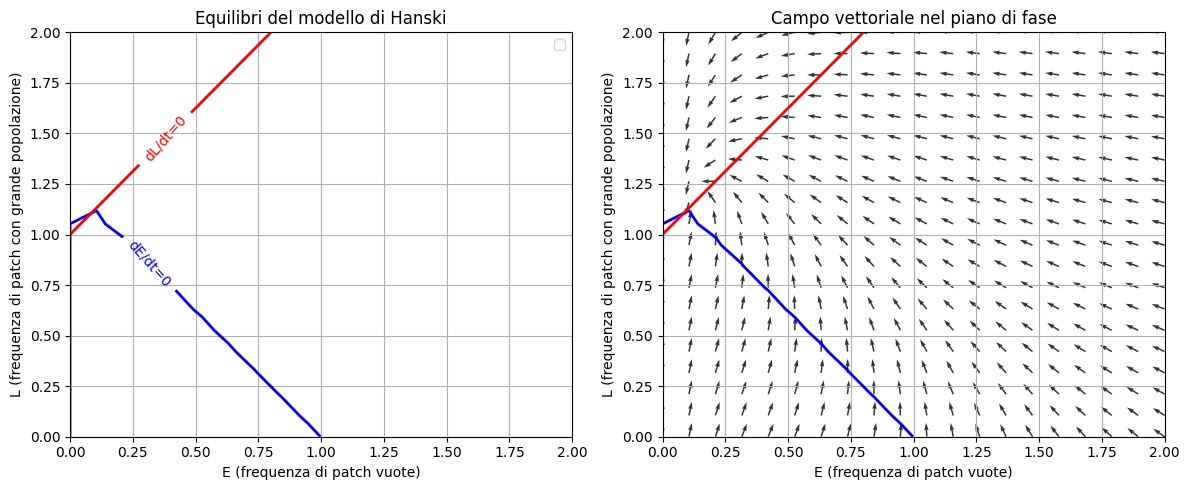

In [25]:
a, b, c = 0.5, 0.8, 0.4
plot_phase_plane(a, b, c)